# Profile of mismatch ratio

This notebook profile the mismatch ratio of all mismatch type under different conditions.

In [1]:
import os, glob, itertools
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")

## 1. Mismatch ratio (all types, barplot)

In [2]:
def get_rmdup_mismatch_ratio(d):
    d = d.copy()
    array = []
    for run, cell in d[["Run", "Cell"]].values:
        m = pd.read_csv("../../../1_NanoNASCseq/results/4_mismatch/3_ratio_rmdup/%s/%s.tsv" % (run, cell), sep="\t", index_col=0)
        m = m[["-" not in i for i in m.index]]
        s = m["Ratio"]
        s.name = cell
        array.append(s)
    m = pd.DataFrame(array)
    for c in m.columns:
        d["%s.Ratio" % c] = m[c].values
    return d
    
data = dict()

tmp = info[(info["Time"] == 3) & (np.isnan(info["ActD"])) & (info["UMIs"] >= 5000)]

d1 = tmp[(tmp["CellLine"] == "K562") & (tmp["s4U"] == 0)]
d2 = tmp[(tmp["CellLine"] == "K562") & (tmp["s4U"] == 50) & (tmp["TC.Ratio"] >= 0.008)]
data["K562.s4U0uM180min"] = d1
data["K562.s4U50uM180min"] = d2
data["K562.s4U0uM180min.Rmdup"] = get_rmdup_mismatch_ratio(d1)
data["K562.s4U50uM180min.Rmdup"] = get_rmdup_mismatch_ratio(d2)

d1 = tmp[(tmp["CellLine"] == "mESC") & (tmp["s4U"] == 0)]
d2 = tmp[(tmp["CellLine"] == "mESC") & (tmp["s4U"] == 400) & (tmp["TC.Ratio"] >= 0.01)]
data["mESC.s4U0uM180min"] = d1
data["mESC.s4U400uM180min"] = d2
data["mESC.s4U0uM180min.Rmdup"] = get_rmdup_mismatch_ratio(d1)
data["mESC.s4U400uM180min.Rmdup"] = get_rmdup_mismatch_ratio(d2)

for k, v in data.items():
    print(len(v), k, sep="\t")

190	K562.s4U0uM180min
105	K562.s4U50uM180min
190	K562.s4U0uM180min.Rmdup
105	K562.s4U50uM180min.Rmdup
64	mESC.s4U0uM180min
110	mESC.s4U400uM180min
64	mESC.s4U0uM180min.Rmdup
110	mESC.s4U400uM180min.Rmdup


--------------------------------------------------------------------------------
K562 rmdup
Median of T-C ratio (%): 0.002658 0.014887
P-value (T-test): 1.8441824535656926e-144
P-value (Mann-Whitney U test): MannwhitneyuResult(statistic=0.0, pvalue=6.999437986710499e-46)


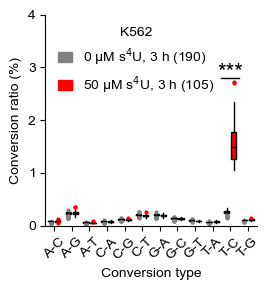

--------------------------------------------------------------------------------
mESC rmdup
Median of T-C ratio (%): 0.002721 0.022216
P-value (T-test): 1.087178232173508e-72
P-value (Mann-Whitney U test): MannwhitneyuResult(statistic=0.0, pvalue=4.555337801313792e-28)


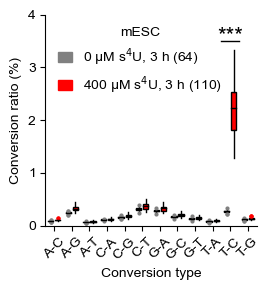

--------------------------------------------------------------------------------
K562 consensus
Median of T-C ratio (%): 0.000167 0.012133
P-value (T-test): 1.1873696625209503e-140
P-value (Mann-Whitney U test): MannwhitneyuResult(statistic=0.0, pvalue=6.999437986710499e-46)


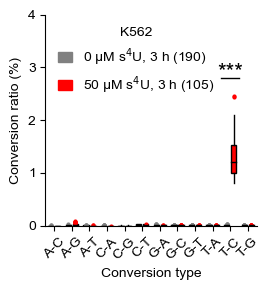

--------------------------------------------------------------------------------
mESC consensus
Median of T-C ratio (%): 0.000357 0.019259
P-value (T-test): 4.8388541718216687e-70
P-value (Mann-Whitney U test): MannwhitneyuResult(statistic=0.0, pvalue=4.555337801313792e-28)


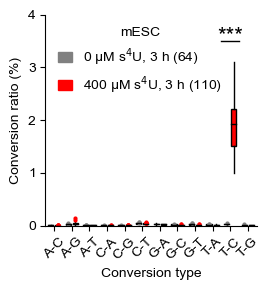

In [3]:
mtypes = ['AC', 'AG', 'AT', 'CA', 'CG', 'CT', 'GA', 'GC', 'GT', 'TA', 'TC', 'TG']

for name in ["rmdup", "consensus"]:
    for cellline in ["K562", "mESC"]:
        print("-" * 80)
        print(cellline, name)
        s4u = 50 if cellline == "K562" else 400
        if name == "rmdup":
            d1 = data["%s.s4U0uM180min.Rmdup" % (cellline)]
            d2 = data["%s.s4U%duM180min.Rmdup" % (cellline, s4u)]
        else:
            d1 = data["%s.s4U0uM180min" % (cellline)]
            d2 = data["%s.s4U%duM180min" % (cellline, s4u)]        

        xs = np.arange(len(mtypes))
        ys1 = [d1["%s.Ratio" % mtype] * 100 for mtype in mtypes]
        ys2 = [d2["%s.Ratio" % mtype] * 100 for mtype in mtypes]

        print("Median of T-C ratio (%):", round(np.median(d1["TC.Ratio"]), 6), round(np.median(d2["TC.Ratio"]), 6))
        print("P-value (T-test):", ttest_ind(d1["TC.Ratio"], d2["TC.Ratio"])[1])
        # assert pvalue < 0.00001
        print("P-value (Mann-Whitney U test):", mannwhitneyu(d1["TC.Ratio"], d2["TC.Ratio"]))
        
        plt.figure(figsize=(2.8, 3))
        box1 = plt.boxplot(ys1, positions=xs - 0.2, widths=0.3, patch_artist=True, 
                           showcaps=False, 
                           boxprops={"facecolor": "grey"},
                           medianprops={"color": "black"},
                           showfliers=True, 
                           flierprops={"markerfacecolor": "grey", "markeredgecolor": "none", "marker": "."})
        box2 = plt.boxplot(ys2, positions=xs + 0.2, widths=0.3, patch_artist=True, 
                           showcaps=False, 
                           boxprops={"facecolor": "red"},
                           medianprops={"color": "black"},
                           showfliers=True, 
                           flierprops={"markerfacecolor": "red", "markeredgecolor": "none", "marker": "."})
        

        y = 2.8
        if cellline == "mESC":
            y = 3.5
        plt.plot([10 - 0.5, 10 + 0.5], [y, y], lw=1, color="black")
        plt.text(10, y + 0.1, "***", va="center", ha="center", size=16)
        #plt.title(name)
        #plt.text(5, 3.6, name)
        plt.xlim(-0.5, 11.5)
        plt.ylim(0, 4)
        ticks = ["%s-%s" % (mt[0], mt[1]) for mt in mtypes]
        plt.xticks(xs, ticks, rotation=45)
        plt.yticks([0, 1, 2, 3, 4])
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.xlabel("Conversion type")
        plt.ylabel("Conversion ratio (%)")
        patch1 = mpatches.Patch(color='grey', label='%d μM s$^4$U, 3 h (%d)' % (0, len(d1)))
        patch2 = mpatches.Patch(color='red', label='%d μM s$^4$U, 3 h (%d)' % (s4u, len(d2)))
        plt.legend(loc="upper left", handles=[patch1, patch2], handlelength=1, frameon=False, title=cellline)
        plt.tight_layout()
        plt.savefig("figures/mismatch_ratio.%s.%s.pdf" % (cellline, name))
        plt.show()
        plt.close()

## 2. Mismatch ratio (time, barplot)

In [60]:
tmp = info[(info["CellLine"] == "K562") & (info["UMIs"] >= 5000) & (np.isnan(info["ActD"]))]
tmp = tmp[tmp["Run"] != "20221014_K562_1"]
tmp = tmp[tmp["Run"] != "20221014_K562_2"]
ds = []
ds.append(tmp[(tmp["s4U"] == 0) & (tmp["Time"] == 3)])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 0.25)])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 0.5)])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 1)])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 2)])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 3)])
print("Cells:", [len(d) for d in ds])

Cells: [167, 32, 51, 41, 44, 161]


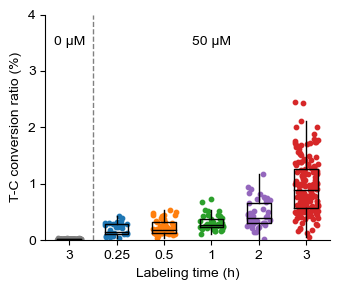

In [64]:
np.random.seed(0)
colors = ["grey", "C0", "C1", "C2", "C4", "C3", "grey", "grey", "grey", "grey"]
w = 0.5
plt.figure(figsize=(3.5, 3))
for i, d in enumerate(ds):
    vs = d["TC.Ratio.Consensus"].values * 100
    plt.boxplot(vs, positions=[i], widths=w, 
                showfliers=False, showcaps=False, medianprops={"color": "black"})
    xs = np.random.random(len(vs)) * w - w/2 + i
    plt.scatter(xs, vs, marker="o", s=10, color=colors[i])

ylim = 4
plt.text(0, ylim * 0.85, "0 μM", ha="center", va="bottom")
plt.text(3, ylim * 0.85, "50 μM", ha="center", va="bottom")
plt.axvline(0.5, lw=1, ls="--", color="grey")

plt.xlabel("Labeling time (h)")
plt.ylabel("T-C conversion ratio (%)")
plt.xticks(np.arange(len(ds)), ["3", "0.25", "0.5", "1", "2", "3"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlim(-0.5, 5.5)
plt.ylim(0, ylim)
plt.yticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig("figures/mismatch_ratio.time.pdf")

## 3. Mismatch ratio (ActD, barplot)

In [66]:
tmp = info[(info["CellLine"] == "K562") & (info["UMIs"] >= 5000)]
tmp = tmp[tmp["Run"] != "20221014_K562_1"] # R10.4.1
tmp = tmp[tmp["Run"] != "20221014_K562_2"]
ds = list()
ds.append(tmp[(tmp["s4U"] == 0) & (tmp["Time"] == 3) & (np.isnan(tmp["ActD"]))])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 3) & (np.isnan(tmp["ActD"]))])
ds.append(tmp[(tmp["s4U"] == 0) & (tmp["Time"] == 3) & (tmp["ActD"] == 3)])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 3) & (tmp["ActD"] == 3)])
ds.append(tmp[(tmp["s4U"] == 0) & (tmp["Time"] == 3) & (tmp["ActD"] == 6)])
ds.append(tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 3) & (tmp["ActD"] == 6)])
print("Cells:", [len(d) for d in ds])

Cells: [167, 161, 68, 63, 81, 59]


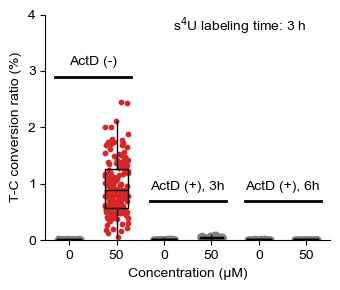

In [67]:
np.random.seed(0)
colors = ["grey", "C3", "grey", "grey", "grey", "grey"]
w = 0.5
plt.figure(figsize=(3.5, 3))
for i, d in enumerate(ds):
    vs = d["TC.Ratio"].values * 100
    plt.boxplot(vs, positions=[i], widths=w, 
                showfliers=False, showcaps=False, medianprops={"color": "black"})
    xs = np.random.random(len(vs)) * w - w/2 + i
    plt.scatter(xs, vs, marker="o", s=10, color=colors[i])
plt.text(5, 3.7, "s$^4$U labeling time: 3 h", ha="right")
plt.ylabel("T-C conversion ratio (%)")
plt.xticks(np.arange(len(ds)), ["0", "50", "0", "50", "0", "50"])
plt.xlabel("Concentration (μM)")
plt.text(0.5, 3.1, "ActD (-)", ha="center")
plt.text(2.5, 0.9, "ActD (+), 3h", ha="center")
plt.text(4.5, 0.9, "ActD (+), 6h", ha="center")
plt.plot([0 - 0.3, 1 + 0.3], [2.9, 2.9], lw=2, color="black")
plt.plot([2 - 0.3, 3 + 0.3], [0.7, 0.7], lw=2, color="black")
plt.plot([4 - 0.3, 5 + 0.3], [0.7, 0.7], lw=2, color="black")
if False:
    for x in [1.5, 3.5]:
        plt.plot([x, x], [0, 3.6], lw=1, ls="--", color="grey")
    for x, y, pval_marker in zip([0, 2, 4], [2.8, 0.8, 0.8], ["***", "NS", "NS"]):
        x1, x2 = x - 0.3, x + 0.3 + 1
        y1, y2 = y, y - 0.1
        plt.plot([x1, x1], [y1, y2], lw=1, color="black")
        plt.plot([x2, x2], [y1, y2], lw=1, color="black")
        plt.plot([x1, x2], [y1, y1], lw=1, color="black")
        if pval_marker == "NS":
            plt.text(x + 0.5, y1 + 0.1, pval_marker, ha="center")
        else:
            plt.text(x + 0.5, y1, pval_marker, ha="center", size=16)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlim(-0.5, 5.5)
plt.ylim(0, 4)
plt.yticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig("figures/mismatch_ratio.actd.pdf")

In [68]:
pvalue1 = ttest_ind(ds[0]["TC.Ratio"].values, ds[1]["TC.Ratio"].values)[1]
pvalue2 = ttest_ind(ds[2]["TC.Ratio"].values, ds[3]["TC.Ratio"].values)[1]
pvalue3 = ttest_ind(ds[4]["TC.Ratio"].values, ds[5]["TC.Ratio"].values)[1]
print(pvalue1, pvalue2, pvalue3)

1.6091679198085997e-79 1.7661615854215048e-19 0.4206554149924151


## 4. Mismatch ratio (concentration, barplot)

### 1. K562

In [69]:
tmp = info[(info["CellLine"] == "K562") & (info["Time"] == 3) & (np.isnan(info["ActD"])) \
            & (info["UMIs"] >= 5000) \
            & ((info["Run"] == "20221014_K562_1") | (info["Run"] == "20221014_K562_2"))]
ds = []
ds.append(tmp[tmp["s4U"] == 0])
ds.append(tmp[tmp["s4U"] == 50])
ds.append(tmp[tmp["s4U"] == 100])
ds.append(tmp[tmp["s4U"] == 200])
ds.append(tmp[tmp["s4U"] == 400])
ds.append(tmp[tmp["s4U"] == 500])
print("Cells:", [len(d) for d in ds], sep="\t")

Cells:	[23, 18, 19, 11, 17, 23]


Mann-Whitney U test: 1.0
Mann-Whitney U test: 5.8010818239051674e-08
Mann-Whitney U test: 3.608935607840402e-08
Mann-Whitney U test: 3.511405610526631e-06
Mann-Whitney U test: 9.547663869726977e-08
Mann-Whitney U test: 6.6368856429973785e-09


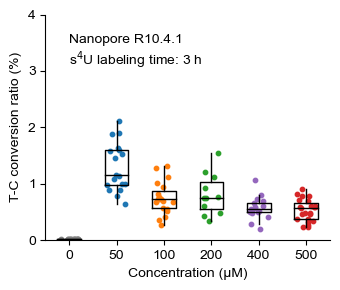

In [70]:
np.random.seed(0)
colors = ["grey", "C0", "C1", "C2", "C4", "C3", "grey", "grey", "grey", "grey"]
w = 0.5
plt.figure(figsize=(3.5, 3))
for i, d in enumerate(ds):
    vs = d["TC.Ratio.Consensus"].values * 100
    if True:
        vs0 = ds[0]["TC.Ratio.Consensus"].values * 100
        pvalue = mannwhitneyu(vs0, vs, alternative="two-sided")[1]
        print("Mann-Whitney U test:", pvalue)
    plt.boxplot(vs, positions=[i], widths=w, showfliers=False, showcaps=False, medianprops={"color": "black"})
    xs = np.random.random(len(vs)) * 0.4 - 0.2 + i
    plt.scatter(xs, vs, marker="o", s=10, color=colors[i])
plt.text(0, 3.5, "Nanopore R10.4.1")
plt.text(0, 3.1, "s$^4$U labeling time: 3 h", ha="left")
plt.xlabel("Concentration (μM)")
plt.ylabel("T-C conversion ratio (%)")
plt.xticks(np.arange(len(ds)), ["0", "50", "100", "200", "400", "500"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlim(-0.5, 5.5)
plt.ylim(-0.0, 4)
plt.yticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig("figures/mismatch_ratio.concentration.pdf")

In [71]:
print("Compared with 50uM:")
for i, d in enumerate(ds):
    vs0 = ds[1]["TC.Ratio"].values * 100
    vs1 = ds[i]["TC.Ratio"].values * 100
    pvalue = mannwhitneyu(vs0, vs1, alternative="two-sided")[1]
    print("Mann-Whitney U test:", pvalue)

Compared with 50uM:
Mann-Whitney U test: 5.8010818239051674e-08
Mann-Whitney U test: 1.0
Mann-Whitney U test: 0.0001973459748431446
Mann-Whitney U test: 0.005705915288936018
Mann-Whitney U test: 3.5317603817201868e-06
Mann-Whitney U test: 2.4416455342659166e-07


### 2. mESC

In [72]:
tmp = info[(info["CellLine"] == "mESC")]
d2 = tmp[(tmp["s4U"] == 50) & (tmp["Time"] == 3) & (np.isnan(tmp["ActD"]))]
d3 = tmp[(tmp["s4U"] == 100) & (tmp["Time"] == 3) & (np.isnan(tmp["ActD"]))]
d4 = tmp[(tmp["s4U"] == 200) & (tmp["Time"] == 3) & (np.isnan(tmp["ActD"]))]
d5 = tmp[(tmp["s4U"] == 400) & (tmp["Time"] == 3) & (np.isnan(tmp["ActD"]))]
d6 = tmp[(tmp["s4U"] == 500) & (tmp["Time"] == 3) & (np.isnan(tmp["ActD"]))]
ds = [d1, d2, d3, d4, d5, d6]
print(len(d1), len(d2), len(d3), len(d4), len(d5), len(d6), sep="\t")

64	81	0	0	121	0


## 5. Overall mismatch ratio

In [3]:
d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
d = d[(d["CellLine"] == "K562") & (d["s4U"] == 0) & (d["Time"] == 3) & (np.isnan(d["ActD"])) & (d["UMIs"] >= 5000)]
print(d.shape)

(190, 49)


In [15]:
def get_overall_mismatch_ratio(path):
    d = pd.read_csv(path, sep="\t", index_col=0)
    s = d["BaseCount"]
    a = s["AC"] + s["CA"] + s["GA"] + s["TA"]
    s = d["EventCount"]
    b = s["AC"] + s["AG"] + s["AT"] \
        + s["CA"] + s["CG"] + s["CT"] \
        + s["GA"] + s["GC"] + s["GT"] \
        + s["TA"] + s["TC"] + s["TG"]
    return b / a

rs = []
for run, cell in d[["Run", "Cell"]].values:
    path = "../../../1_NanoNASCseq/results/4_mismatch/3_ratio_rmdup/%s/%s.tsv" % (run, cell)
    rs.append(get_overall_mismatch_ratio(path))

Size: 190
Mean: 0.004221542224532216
Std: 0.0004117658637363363
Median: 0.004281557924775705


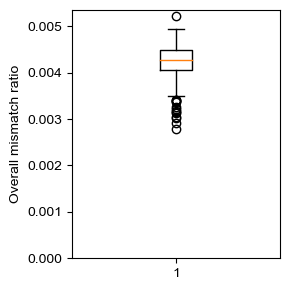

In [19]:
print("Size:", len(rs))
print("Mean:", np.mean(rs))
print("Std:", np.std(rs))
print("Median:", np.median(rs))
plt.figure(figsize=(3, 3))
plt.boxplot(rs)
plt.ylabel("Overall mismatch ratio")
plt.ylim(0, None)
plt.tight_layout()
plt.show()
plt.close()